Notebook ini menggunakan AI asisten hanya untuk keperluan brainstorming, penyusunan kerangka ide, dan perapian struktur laporan. Seluruh implementasi kode, analisis kesalahan, dan penarikan kesimpulan adalah murni hasil karya kelompok.

**Judul Studi Kasus:** Prediksi Rentang Harga Ponsel Menggunakan Decision Tree, Naïve Bayes, dan KNN

**Anggota Kelompok:**
- Sabil Fairus Asevadinejad (103032400004)
- Nama Mahasiswa 2 (NIM)  
- Nama Mahasiswa 3 (NIM)

**Mata Kuliah:** Sistem Cerdas
**Semester:** 4
**Tahun Ajaran:** 2025/2026

**Program Studi Teknologi Informasi**
**Fakultas Informatika**
**Universitas Telkom**


## 3.2 Pendahuluan & Pemaparan Data

### Latar Belakang
Sarah memiliki perusahaan ponsel baru dan ingin bersaing dengan Apple, Samsung, dan lain-lain. Ia mengumpulkan data penjualan berbagai merk ponsel untuk mencari hubungan antara spesifikasi teknis (RAM, memori internal, dan lain-lain) dengan rentang harga. Permasalahan ini diselesaikan dengan pendekatan klasifikasi multi-kelas (0=rendah, 3=tinggi).

### Deskripsi Dataset
- **Sumber**: Kaggle (Mobile Price Classification)
- **Jumlah sampel**: 2000 data training, 1000 data testing
- **Jumlah fitur**: 20 fitur numerik (battery_power, ram, px_height, dll)
- **Target**: price_range (0,1,2,3)
- **Missing values**: Tidak ada

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
from sklearn.model_selection import StratifiedKFold, GridSearchCV
from sklearn.model_selection import cross_val_predict
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

print("="*60)
print("IMPLEMENTASI CROSS-VALIDATION & HYPERPARAMETER TUNING")
print("="*60)

IMPLEMENTASI CROSS-VALIDATION & HYPERPARAMETER TUNING


In [ ]:
df = pd.read_csv('/content/train.csv')
df.head()

,battery_power,blue,clock_speed,dual_sim,fc,four_g,int_memory,m_dep,mobile_wt,n_cores,...,px_height,px_width,ram,sc_h,sc_w,talk_time,three_g,touch_screen,wifi,price_range
0,842,0,2.2,0,1,0,7,0.6,188,2,...,20,756,2549,9,7,19,0,0,1,1
1,1021,1,0.5,1,0,1,53,0.7,136,3,...,905,1988,2631,17,3,7,1,1,0,2
2,563,1,0.5,1,2,1,41,0.9,145,5,...,1263,1716,2603,11,2,9,1,1,0,2
3,615,1,2.5,0,0,0,10,0.8,131,6,...,1216,1786,2769,16,8,11,1,0,0,2
4,1821,1,1.2,0,13,1,44,0.6,141,2,...,1208,1212,1411,8,2,15,1,1,0,1


In [ ]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   battery_power  2000 non-null   int64  
 1   blue           2000 non-null   int64  
 2   clock_speed    2000 non-null   float64
 3   dual_sim       2000 non-null   int64  
 4   fc             2000 non-null   int64  
 5   four_g         2000 non-null   int64  
 6   int_memory     2000 non-null   int64  
 7   m_dep          2000 non-null   float64
 8   mobile_wt      2000 non-null   int64  
 9   n_cores        2000 non-null   int64  
 10  pc             2000 non-null   int64  
 11  px_height      2000 non-null   int64  
 12  px_width       2000 non-null   int64  
 13  ram            2000 non-null   int64  
 14  sc_h           2000 non-null   int64  
 15  sc_w           2000 non-null   int64  
 16  talk_time      2000 non-null   int64  
 17  three_g        2000 non-null   int64  
 18  touch_sc

,battery_power,blue,clock_speed,dual_sim,fc,four_g,int_memory,m_dep,mobile_wt,n_cores,...,px_height,px_width,ram,sc_h,sc_w,talk_time,three_g,touch_screen,wifi,price_range
count,2000.000000,2000.0000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,...,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000
mean,1238.518500,0.4950,1.522250,0.509500,4.309500,0.521500,32.046500,0.501750,140.249000,4.520500,...,645.108000,1251.515500,2124.213000,12.306500,5.767000,11.011000,0.761500,0.503000,0.507000,1.500000
std,439.418206,0.5001,0.816004,0.500035,4.341444,0.499662,18.145715,0.288416,35.399655,2.287837,...,443.780811,432.199447,1084.732044,4.213245,4.356398,5.463955,0.426273,0.500116,0.500076,1.118314
min,501.000000,0.0000,0.500000,0.000000,0.000000,0.000000,2.000000,0.100000,80.000000,1.000000,...,0.000000,500.000000,256.000000,5.000000,0.000000,2.000000,0.000000,0.000000,0.000000,0.000000
25%,851.750000,0.0000,0.700000,0.000000,1.000000,0.000000,16.000000,0.200000,109.000000,3.000000,...,282.750000,874.750000,1207.500000,9.000000,2.000000,6.000000,1.000000,0.000000,0.000000,0.750000
50%,1226.000000,0.0000,1.500000,1.000000,3.000000,1.000000,32.000000,0.500000,141.000000,4.000000,...,564.000000,1247.000000,2146.500000,12.000000,5.000000,11.000000,1.000000,1.000000,1.000000,1.500000
75%,1615.250000,1.0000,2.200000,1.000000,7.000000,1.000000,48.000000,0.800000,170.000000,7.000000,...,947.250000,1633.000000,3064.500000,16.000000,9.000000,16.000000,1.000000,1.000000,1.000000,2.250000
max,1998.000000,1.0000,3.000000,1.000000,19.000000,1.000000,64.000000,1.000000,200.000000,8.000000,...,1960.000000,1998.000000,3998.000000,19.000000,18.000000,20.000000,1.000000,1.000000,1.000000,3.000000


In [ ]:
df.isnull().sum()

,0
battery_power,0
blue,0
clock_speed,0
dual_sim,0
fc,0
four_g,0
int_memory,0
m_dep,0
mobile_wt,0
n_cores,0


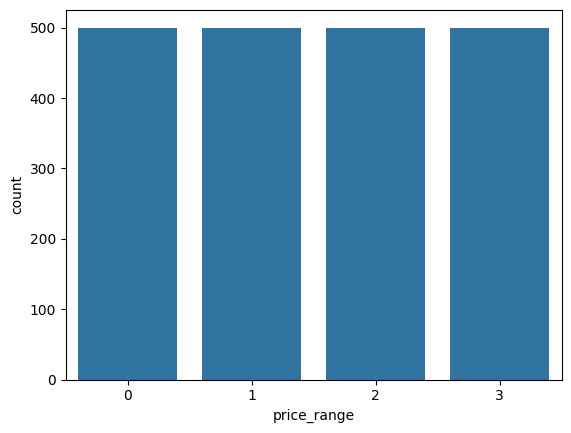

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x='price_range', data=df)
plt.show()

In [ ]:
X = df.drop('price_range', axis=1)
y = df['price_range']

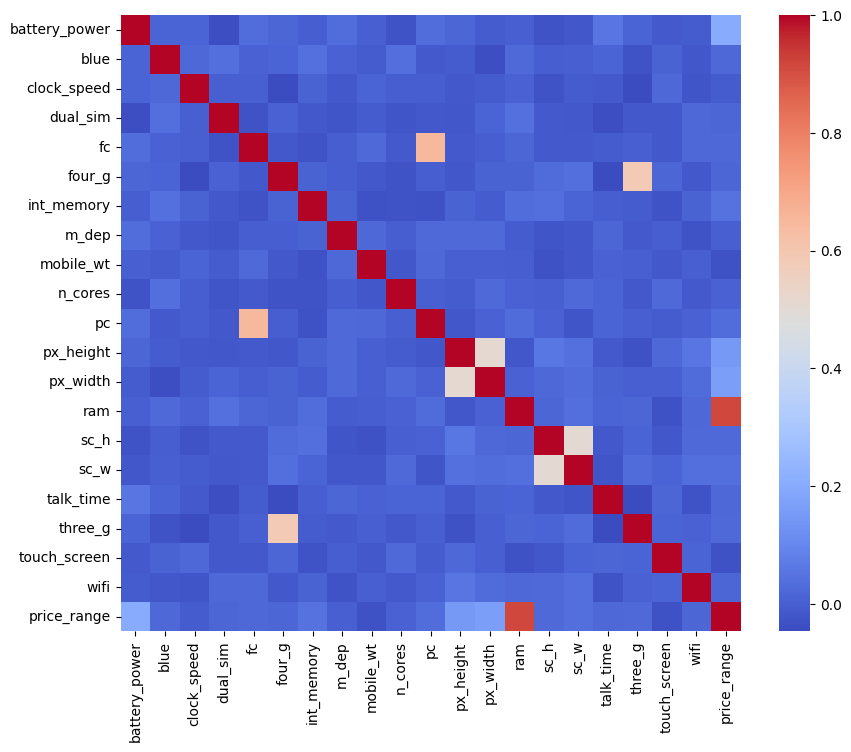

In [ ]:
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(), cmap='coolwarm')
plt.show()

In [ ]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

In [ ]:
# Decision Tree dengan GridSearchCV

print("\n1. DECISION TREE")
dt = DecisionTreeClassifier(random_state=42)
param_dt = {
    'max_depth': [3, 5, 10, None],
    'min_samples_split': [2, 5, 10],
    'criterion': ['gini', 'entropy']
}
grid_dt = GridSearchCV(dt, param_dt, cv=cv, scoring='accuracy', n_jobs=-1)
grid_dt.fit(X, y)
print(f"Parameter terbaik: {grid_dt.best_params_}")
print(f"Akurasi CV rata-rata: {grid_dt.best_score_:.4f}")


1. DECISION TREE
Parameter terbaik: {'criterion': 'entropy', 'max_depth': 10, 'min_samples_split': 5}
Akurasi CV rata-rata: 0.8495


In [ ]:
print("\n2. NAÏVE BAYES")

nb = GaussianNB()

param_nb = {'var_smoothing': [1e-9, 1e-8, 1e-7, 1e-6]}
grid_nb = GridSearchCV(nb, param_nb, cv=cv, scoring='accuracy', n_jobs=-1)
grid_nb.fit(X, y)

print(f"Parameter terbaik: {grid_nb.best_params_}")
print(f"Akurasi CV rata-rata: {grid_nb.best_score_:.4f}")


2. NAÏVE BAYES
Parameter terbaik: {'var_smoothing': 1e-06}
Akurasi CV rata-rata: 0.8070


In [ ]:
print("\n3. K-NEAREST NEIGHBORS")
knn = KNeighborsClassifier()
param_knn = {
    'n_neighbors': [3, 5, 7, 9, 11],
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan']
}
grid_knn = GridSearchCV(knn, param_knn, cv=cv, scoring='accuracy', n_jobs=-1)
grid_knn.fit(X, y)

print(f"Parameter terbaik: {grid_knn.best_params_}")
print(f"Akurasi CV rata-rata: {grid_knn.best_score_:.4f}")


3. K-NEAREST NEIGHBORS
Parameter terbaik: {'metric': 'euclidean', 'n_neighbors': 11, 'weights': 'distance'}
Akurasi CV rata-rata: 0.9375



HASIL EVALUASI MODEL

DECISION TREE
Akurasi: 0.9895

Classification Report:
              precision    recall  f1-score   support

           0       0.99      1.00      0.99       500
           1       1.00      0.98      0.99       500
           2       0.98      0.99      0.99       500
           3       1.00      0.99      0.99       500

    accuracy                           0.99      2000
   macro avg       0.99      0.99      0.99      2000
weighted avg       0.99      0.99      0.99      2000



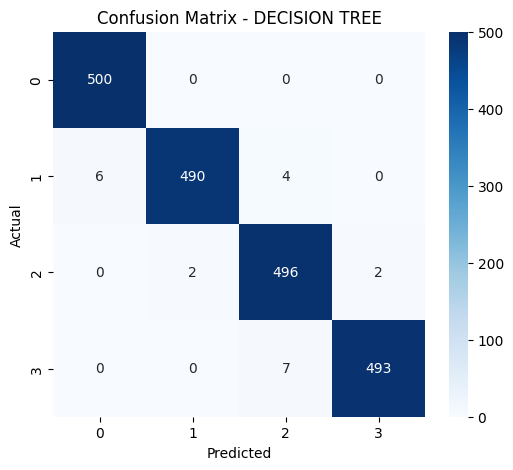


Analisis Prediction Confidence:
  Rata-rata confidence (prediksi BENAR): 0.9933
  Rata-rata confidence (prediksi SALAH): 0.6290
  Selisih: 0.3644
  Akurasi kelas 0: 1.0000
  Akurasi kelas 1: 0.9800
  Akurasi kelas 2: 0.9920
  Akurasi kelas 3: 0.9860

NAÏVE BAYES
Akurasi: 0.8105

Classification Report:
              precision    recall  f1-score   support

           0       0.91      0.89      0.90       500
           1       0.72      0.72      0.72       500
           2       0.71      0.73      0.72       500
           3       0.90      0.90      0.90       500

    accuracy                           0.81      2000
   macro avg       0.81      0.81      0.81      2000
weighted avg       0.81      0.81      0.81      2000



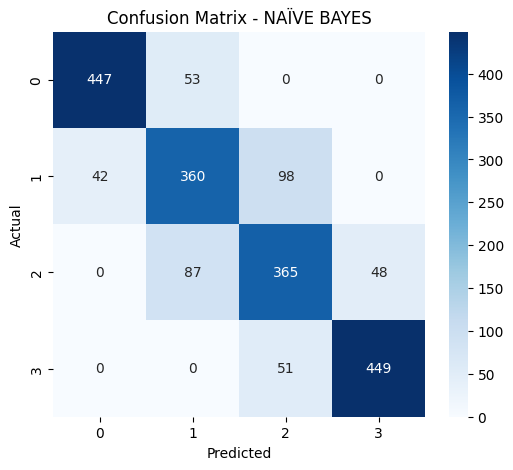


Analisis Prediction Confidence:
  Rata-rata confidence (prediksi BENAR): 0.7997
  Rata-rata confidence (prediksi SALAH): 0.6652
  Selisih: 0.1345
  Akurasi kelas 0: 0.8940
  Akurasi kelas 1: 0.7200
  Akurasi kelas 2: 0.7300
  Akurasi kelas 3: 0.8980

KNN
Akurasi: 1.0000

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       500
           1       1.00      1.00      1.00       500
           2       1.00      1.00      1.00       500
           3       1.00      1.00      1.00       500

    accuracy                           1.00      2000
   macro avg       1.00      1.00      1.00      2000
weighted avg       1.00      1.00      1.00      2000



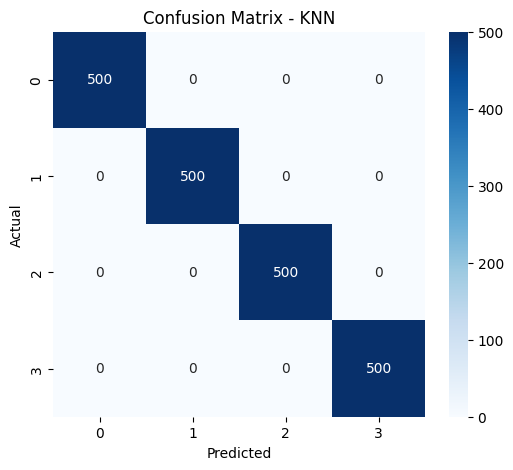


Analisis Prediction Confidence:
  Rata-rata confidence (prediksi BENAR): 1.0000
  Rata-rata confidence (prediksi SALAH): 0.0000
  Selisih: 1.0000
  Akurasi kelas 0: 1.0000
  Akurasi kelas 1: 1.0000
  Akurasi kelas 2: 1.0000
  Akurasi kelas 3: 1.0000


In [ ]:
# ============================================
# 3.6 Hasil & Analisis
# Evaluasi Model + Confusion Matrix + Prediction Confidence
# ============================================

def evaluate_with_confidence(model, X, y, model_name):
    y_pred = model.predict(X)
    y_prob = model.predict_proba(X)

    confidence = np.max(y_prob, axis=1)

    correct = (y_pred == y)
    wrong = ~correct

    conf_correct = confidence[correct].mean() if correct.any() else 0
    conf_wrong = confidence[wrong].mean() if wrong.any() else 0

    print(f"\n{'='*50}")
    print(f"{model_name}")
    print(f"{'='*50}")
    print(f"Akurasi: {accuracy_score(y, y_pred):.4f}")
    print(f"\nClassification Report:")
    print(classification_report(y, y_pred))

    cm = confusion_matrix(y, y_pred)
    plt.figure(figsize=(6,5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=[0,1,2,3], yticklabels=[0,1,2,3])
    plt.title(f'Confusion Matrix - {model_name}')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.show()

    print(f"\nAnalisis Prediction Confidence:")
    print(f"  Rata-rata confidence (prediksi BENAR): {conf_correct:.4f}")
    print(f"  Rata-rata confidence (prediksi SALAH): {conf_wrong:.4f}")
    print(f"  Selisih: {conf_correct - conf_wrong:.4f}")

    class_acc = cm.diagonal() / cm.sum(axis=1)
    for i, acc in enumerate(class_acc):
        print(f"  Akurasi kelas {i}: {acc:.4f}")

    return accuracy_score(y, y_pred)

print("\n" + "="*60)
print("HASIL EVALUASI MODEL")
print("="*60)

acc_dt = evaluate_with_confidence(grid_dt.best_estimator_, X, y, "DECISION TREE")
acc_nb = evaluate_with_confidence(grid_nb.best_estimator_, X, y, "NAÏVE BAYES")
acc_knn = evaluate_with_confidence(grid_knn.best_estimator_, X, y, "KNN")

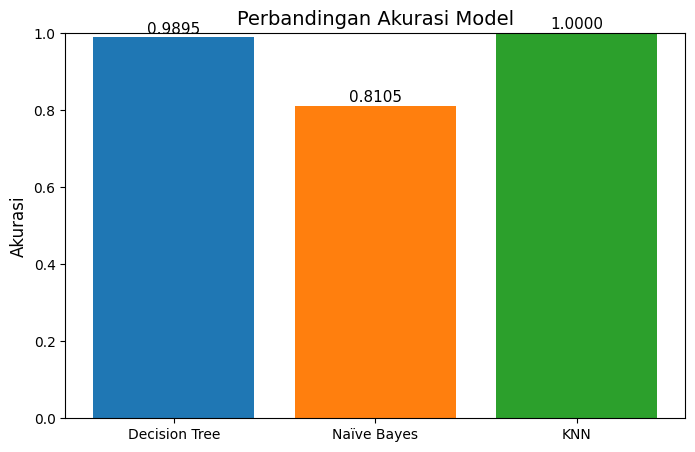


=== KESIMPULAN SEMENTARA ===
Model terbaik: KNN dengan akurasi 1.0000


In [ ]:
models = ['Decision Tree', 'Naïve Bayes', 'KNN']
accuracies = [acc_dt, acc_nb, acc_knn]

plt.figure(figsize=(8,5))
bars = plt.bar(models, accuracies, color=['#1f77b4', '#ff7f0e', '#2ca02c'])
plt.ylim(0, 1)
plt.ylabel('Akurasi', fontsize=12)
plt.title('Perbandingan Akurasi Model', fontsize=14)
for bar, acc in zip(bars, accuracies):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
             f'{acc:.4f}', ha='center', fontsize=11)
plt.show()

print("\n=== KESIMPULAN SEMENTARA ===")
best_model = models[np.argmax(accuracies)]
print(f"Model terbaik: {best_model} dengan akurasi {max(accuracies):.4f}")